In [8]:
import pandas as pd

In [86]:
import matplotlib.pyplot as plt

In [10]:
caminho = r"C:\Projetos\LearningDataAnalysis\dados\microdados_enem_2018\DADOS\MICRODADOS_ENEM_2018.csv"

In [11]:
microdadosEnem = pd.read_csv(caminho, sep=";", encoding='ISO-8859-1')

In [14]:
microdadosEnem.columns.values

<StringArray>
[          'NU_INSCRICAO',                 'NU_ANO',        'TP_FAIXA_ETARIA',
                'TP_SEXO',        'TP_ESTADO_CIVIL',            'TP_COR_RACA',
       'TP_NACIONALIDADE',        'TP_ST_CONCLUSAO',        'TP_ANO_CONCLUIU',
              'TP_ESCOLA',              'TP_ENSINO',           'IN_TREINEIRO',
       'CO_MUNICIPIO_ESC',       'NO_MUNICIPIO_ESC',              'CO_UF_ESC',
              'SG_UF_ESC', 'TP_DEPENDENCIA_ADM_ESC',     'TP_LOCALIZACAO_ESC',
        'TP_SIT_FUNC_ESC',     'CO_MUNICIPIO_PROVA',     'NO_MUNICIPIO_PROVA',
            'CO_UF_PROVA',            'SG_UF_PROVA',         'TP_PRESENCA_CN',
         'TP_PRESENCA_CH',         'TP_PRESENCA_LC',         'TP_PRESENCA_MT',
            'CO_PROVA_CN',            'CO_PROVA_CH',            'CO_PROVA_LC',
            'CO_PROVA_MT',             'NU_NOTA_CN',             'NU_NOTA_CH',
             'NU_NOTA_LC',             'NU_NOTA_MT',        'TX_RESPOSTAS_CN',
        'TX_RESPOSTAS_CH',        'TX_

In [62]:
colunasSelecionadas = ['NU_INSCRICAO', 'SG_UF_ESC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO', 'Q001', 'Q002']

In [63]:
microdadosEnemSelecionado = microdadosEnem.filter(items = colunasSelecionadas).dropna()

In [64]:
q001e002Dicionario = {
'A': 'Nunca Estudou',
'B': 'Não completou a 4ª série/5º ano do Ensino Fundamental.',
'C': 'Completou a 4ª série/5º ano, mas não completou a 8ª série/9º ano do Ensino Fundamental.',
'D': 'Completou a 8ª série/9º ano do Ensino Fundamental, mas não completou o Ensino Médio.',
'E': 'Completou o Ensino Médio, mas não completou a Faculdade.',
'F': 'Completou a Faculdade, mas não completou a Pós-graduação.',
'G': 'Completou a Pós-graduação.',
'H': 'Não sei.'
}

In [65]:
microdadosEnemSelecionado['NO_Q001'] = [q001e002Dicionario[resp] for resp in microdadosEnemSelecionado.Q001]

In [66]:
microdadosEnemSelecionado['NO_Q002'] = [q001e002Dicionario[resp] for resp in microdadosEnemSelecionado.Q002]

In [70]:
microdadosEnemSelecionado['SG_UF_ESC'] = microdadosEnem.SG_UF_ESC

In [71]:
microdadosEnemSelecionado.head()

,NU_INSCRICAO,SG_UF_ESC,NU_NOTA_MT,NU_NOTA_REDACAO,Q001,Q002,NO_Q001,NO_Q002,UF_ESC
0,180007186625,PA,496.3,360.0,E,E,"Completou o Ensino Médio, mas não completou a ...","Completou o Ensino Médio, mas não completou a ...",PA
2,180007186628,MG,410.4,600.0,B,B,Não completou a 4ª série/5º ano do Ensino Fund...,Não completou a 4ª série/5º ano do Ensino Fund...,MG
3,180007186629,PA,711.5,800.0,F,F,"Completou a Faculdade, mas não completou a Pós...","Completou a Faculdade, mas não completou a Pós...",PA
5,180007186632,MG,534.9,540.0,E,E,"Completou o Ensino Médio, mas não completou a ...","Completou o Ensino Médio, mas não completou a ...",MG
11,180007186638,BA,481.6,680.0,E,D,"Completou o Ensino Médio, mas não completou a ...",Completou a 8ª série/9º ano do Ensino Fundamen...,BA


In [72]:
microdadosEnemSelecionado.filter(items = ['NU_NOTA_REDACAO', 'NO_Q002'])\
            .where(microdadosEnemSelecionado.SG_UF_ESC == 'RJ')\
            .groupby('NO_Q002')\
            .mean().sort_values(by='NU_NOTA_REDACAO', ascending=False)

,NU_NOTA_REDACAO
NO_Q002,
Completou a Pós-graduação.,704.009604
"Completou a Faculdade, mas não completou a Pós-graduação.",661.576719
"Completou o Ensino Médio, mas não completou a Faculdade.",554.315077
"Completou a 8ª série/9º ano do Ensino Fundamental, mas não completou o Ensino Médio.",510.333559
"Completou a 4ª série/5º ano, mas não completou a 8ª série/9º ano do Ensino Fundamental.",492.409086
Não completou a 4ª série/5º ano do Ensino Fundamental.,468.303673
Não sei.,468.185802
Nunca Estudou,427.912371


<Axes: xlabel='Q002'>

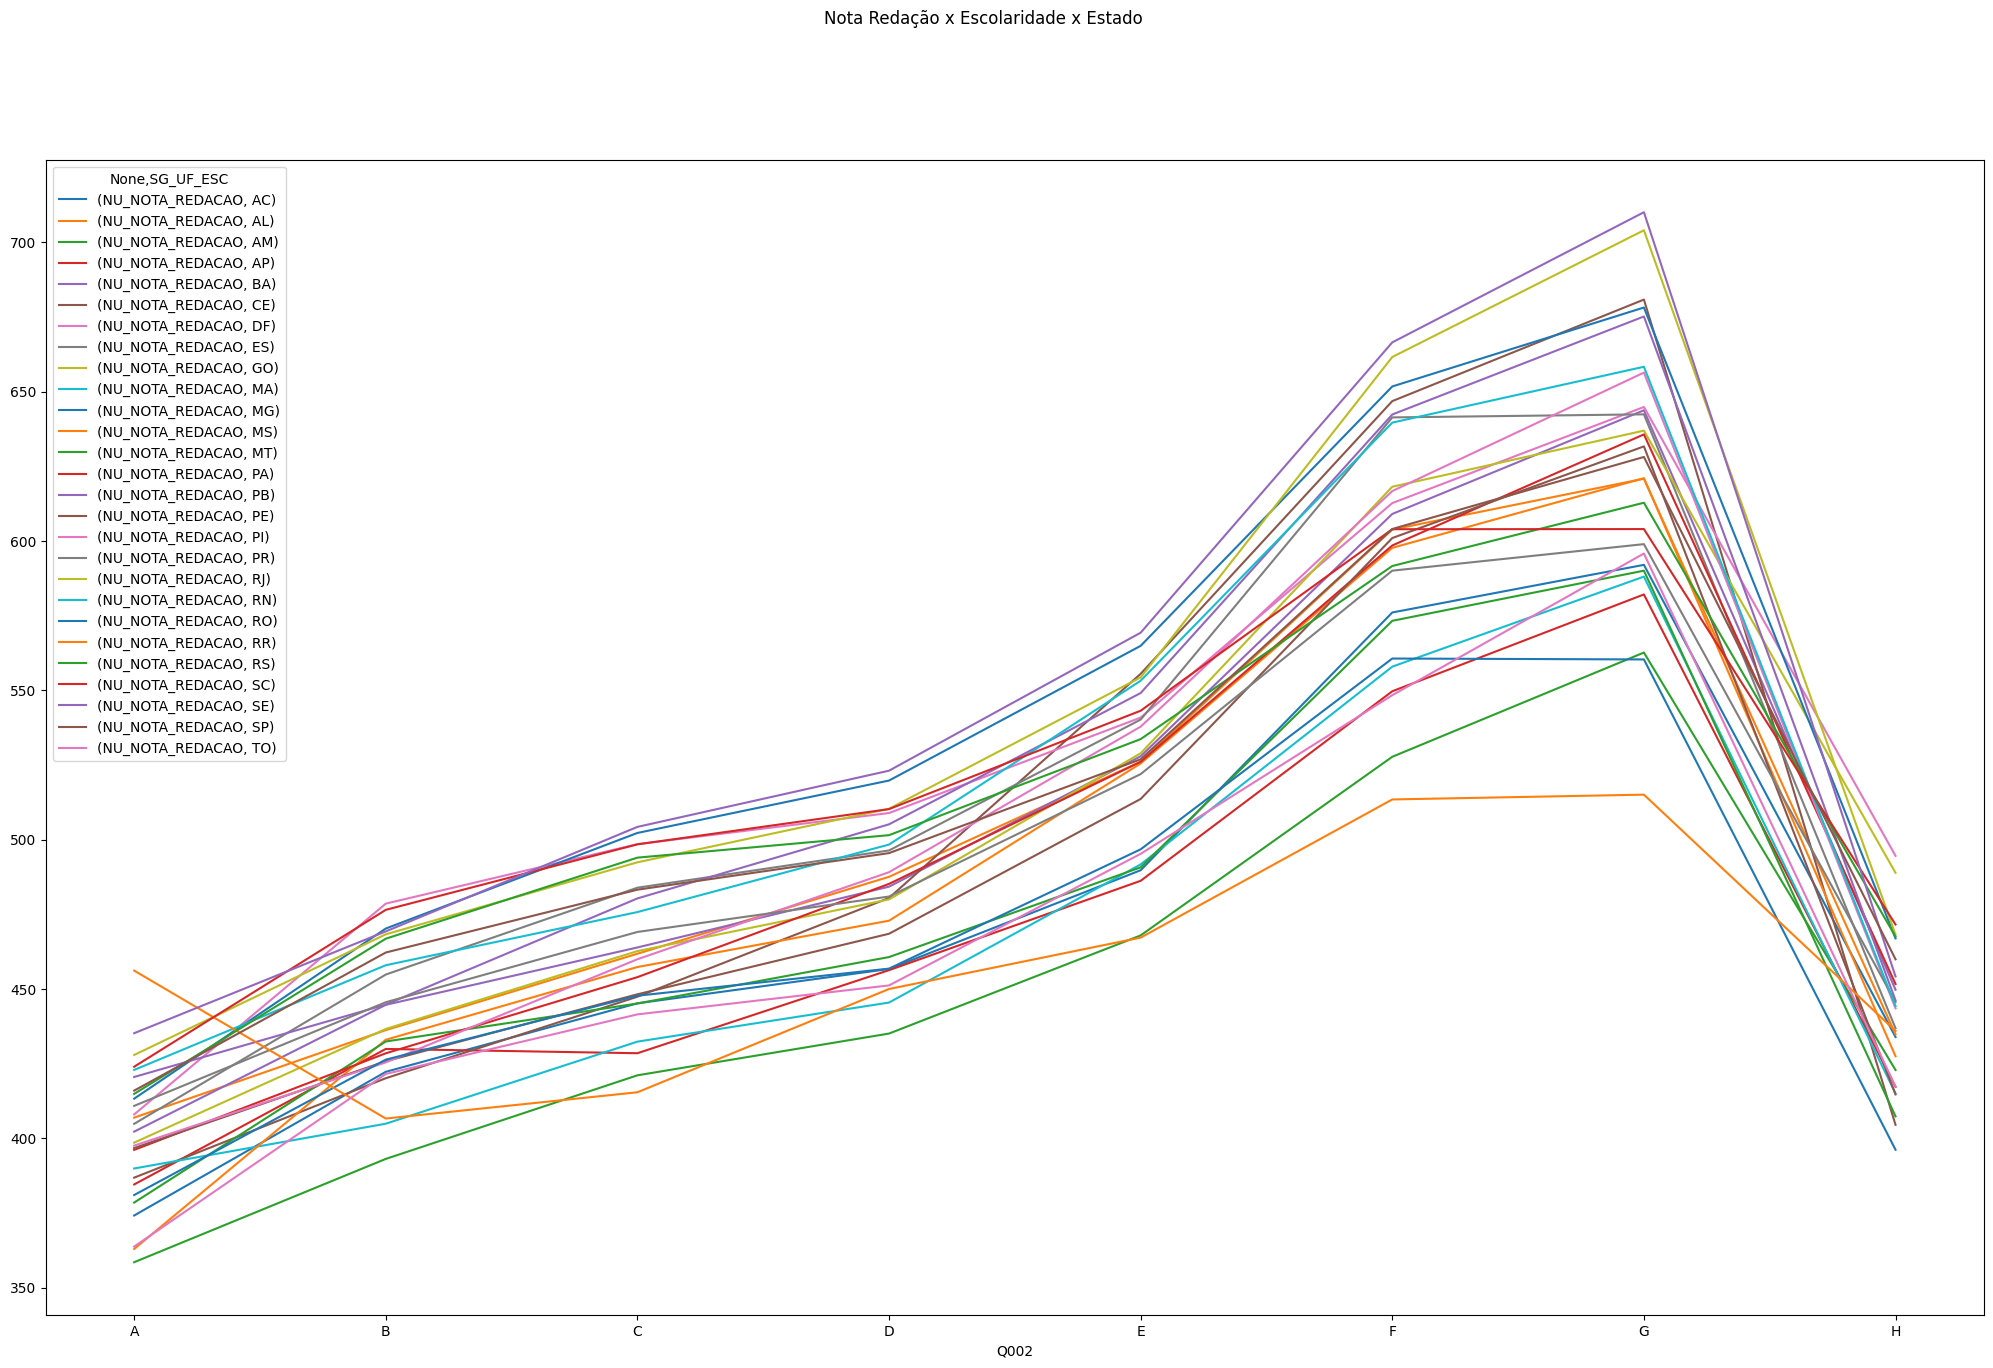

In [94]:
fig, ax = plt.subplots(figsize=(25, 15))
plt.suptitle('Nota Redação x Escolaridade x Estado')
microdadosEnemSelecionado.filter(items = ['SG_UF_ESC','Q002', 'NU_NOTA_REDACAO'])\
            .groupby(['Q002', 'SG_UF_ESC'])\
            .mean().sort_values(by='NU_NOTA_REDACAO', ascending=False)\
            .unstack().plot(ax=ax)